<a href="https://colab.research.google.com/github/RiccardoPerin/MRI_Tumor_Classification/blob/main/main_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Brain Tumor MRI Classification - NNDL Project**

### **Authors:** Pennino Marcello, Perin Riccardo, Zatti Giovanni

**Description:** This project implements three progressively complex architectures to classify brain MRI scans into four distinct categories: **Glioma**, **Meningioma**, **Pituitary**, and **No Tumor**.

---

## **Architectural Stages:**

* ### **1. Base Stage**
  * **Model:** Convolutional Autoencoder (CAE)
  * **Strategy:** Unsupervised pre-training followed by a supervised classification head.

* ### **2. Intermediate Stage**
  * **Model:** ResNet-50 + Grad-CAM
  * **Strategy:** Transfer learning for feature extraction and classification, combined with Grad-CAM for model explainability and visual activation mapping.

* ### **3. Advanced Stage**
  * **Model:** Vision Transformer (ViT-B/16)
  * **Strategy:** Attention-based approach to capture global context and long-range spatial dependencies within the MRI images.



---
## **Section 1 — Environment Setup & Kaggle API**

In this section we initialize the workspace environment on Google Colab, ensuring both pipeline reproducibility and hardware optimization before loading the dataset.

#### **Key Steps:**
* **Reproducibility:** Fixes seeds across `random`, `numpy`, and `PyTorch` (`CUDA` deterministic backends) to guarantee identical results across runs.
* **Hardware Detection:** Identifies the available runtime device (`CPU` vs `GPU`) and extracts VRAM specifications if acceleration is active.
* **Data Ingestion:** Automates the quiet installation of the Kaggle CLI, authenticates via API environment variables, downloads the *Brain Tumor MRI Dataset*, and extracts the structured directories.

In [1]:
import os
import sys
import random
import zipfile
import subprocess
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm #Needed for GradCam
from PIL import Image
from tqdm.auto import tqdm #Useful to plot progress bar

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
  GPU  : Tesla T4
  VRAM : 15.6 GB


In [2]:
from google.colab import files
import shutil
from google.colab import drive

drive.mount('/content/drive')   # safe to call even if already mounted

DRIVE_KAGGLE_JSON = Path('/content/drive/MyDrive/brain_tumor_project/kaggle.json')
KAGGLE_DIR        = Path.home() / '.kaggle'
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
kaggle_json_path  = KAGGLE_DIR / 'kaggle.json'

if DRIVE_KAGGLE_JSON.exists():
    shutil.copy(DRIVE_KAGGLE_JSON, kaggle_json_path)
    print(f'Loaded kaggle.json from Drive: {DRIVE_KAGGLE_JSON}')
else:
    print('No kaggle.json found on Drive yet -- upload it once:')
    from google.colab import files
    uploaded = files.upload()                 # opens a browser file picker
    uploaded_name = next(iter(uploaded))
    shutil.move(uploaded_name, kaggle_json_path)

    # Save a copy to Drive so future sessions skip the upload step entirely
    DRIVE_KAGGLE_JSON.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(kaggle_json_path, DRIVE_KAGGLE_JSON)
    print(f'Saved a copy to Drive at {DRIVE_KAGGLE_JSON} for next time.')

kaggle_json_path.chmod(0o600)                 # Kaggle CLI refuses to run if permissions are too open

# Install Kaggle CLI quietly
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'], check=True)

DATASET_SLUG = 'masoudnickparvar/brain-tumor-mri-dataset'
DOWNLOAD_DIR = Path('/content/data')
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

print(f'Downloading {DATASET_SLUG} ...')
subprocess.run(
    ['kaggle', 'datasets', 'download', '-d', DATASET_SLUG, '-p', str(DOWNLOAD_DIR)],
    check=True,
)

# Find and extract the zip (filename may vary slightly across API versions)
zip_files = list(DOWNLOAD_DIR.glob('*.zip'))
assert zip_files, 'No zip file found after download!'
zip_path = zip_files[0]
print(f'Extracting {zip_path.name} ...')
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(DOWNLOAD_DIR)
print('Extraction complete.')

# ── Inspect structure ─────────────────────────────────────────────────────────
rows = []
for split_dir in sorted(DOWNLOAD_DIR.iterdir()):
    if not split_dir.is_dir():
        continue
    for cls_dir in sorted(split_dir.iterdir()):
        if cls_dir.is_dir():
            n_files = len(list(cls_dir.glob('*')))
            rows.append((split_dir.name, cls_dir.name, n_files))

# ── Render as a plain ASCII table ─────────────────────────────────────────────
col_split = max(len('split'), max(len(r[0]) for r in rows))
col_class = max(len('class'), max(len(r[1]) for r in rows))
col_files = max(len('files'), max(len(str(r[2])) for r in rows))

def _row(a, b, c):
    return f'| {a:<{col_split}} | {b:<{col_class}} | {c:>{col_files}} |'

separator = f"+{'-' * (col_split + 2)}+{'-' * (col_class + 2)}+{'-' * (col_files + 2)}+"

print('Dataset structure after extraction:')
print(separator)
print(_row('split', 'class', 'files'))
print(separator)
for split, cls, n_files in rows:
    print(_row(split, cls, str(n_files)))
print(separator)

Mounted at /content/drive
Loaded kaggle.json from Drive: /content/drive/MyDrive/brain_tumor_project/kaggle.json
Extracting brain-tumor-mri-dataset.zip ...
Extraction complete.
Dataset structure after extraction:
+----------+------------+-------+
| split    | class      | files |
+----------+------------+-------+
| Testing  | glioma     |   400 |
| Testing  | meningioma |   400 |
| Testing  | notumor    |   400 |
| Testing  | pituitary  |   400 |
| Training | glioma     |  1400 |
| Training | meningioma |  1400 |
| Training | notumor    |  1400 |
| Training | pituitary  |  1400 |
+----------+------------+-------+


---
## **Section 2 — Data Pipeline**

In this section we build a robust pipeline, transforming raw MRI scans into optimized tensors ready for neural network consumption.

In [3]:
# ── Dataset constants ────────────────────────────────────────────────────────
# The Kaggle dataset provides Training/ and Testing/ folders,
# each containing four class subfolders (lowercase names).
# Adjust CLASS_NAMES if your extraction shows different capitalisation.

TRAIN_ROOT  = DOWNLOAD_DIR / 'Training'
TEST_ROOT   = DOWNLOAD_DIR / 'Testing'
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

IMG_SIZE       = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]

print('Class → index mapping:', CLASS_TO_IDX)


class BrainTumorDataset(Dataset):
    '''
    Custom PyTorch Dataset for the Brain Tumor MRI dataset.

    Scans each class subfolder inside `root_dir` and collects
    (image_path, label_index) pairs.  Supports pre-computed file
    lists so that train/val splits can share a single scan pass.

    Args:
        root_dir    : Path to the folder containing class subfolders.
        class_names : Ordered list of class subfolder names.
        transform   : torchvision transform applied to each PIL image.
        file_list   : Optional pre-built [(Path, int)] list (for splits).
    '''

    def __init__(
        self,
        root_dir: Path,
        class_names: List[str],
        transform: Optional[transforms.Compose] = None,
        file_list: Optional[List[Tuple[Path, int]]] = None,
    ):
        self.root_dir    = root_dir
        self.class_names = class_names
        self.transform   = transform
        self.samples     = file_list if file_list is not None else self._scan()

    def _scan(self) -> List[Tuple[Path, int]]:
        '''Walk class folders and collect (image_path, label_index) pairs.'''
        samples = []
        for cls in self.class_names:
            cls_dir = self.root_dir / cls
            if not cls_dir.exists():
                raise FileNotFoundError(f'Class folder not found: {cls_dir}')
            label = CLASS_TO_IDX[cls]
            for ext in ('*.jpg', '*.jpeg', '*.png'):
                for img_path in sorted(cls_dir.glob(ext)):
                    samples.append((img_path, label))
        return samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        img_path, label = self.samples[idx]
        # Convert to RGB so grayscale DICOM-derived PNGs work uniformly
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

Class → index mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [4]:
# ── Transforms ───────────────────────────────────────────────────────────────
# Training: geometric and colour augmentations reduce overfitting.
# Validation / Test: only resize + normalise (no stochastic ops).

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── 80 / 10 / 10 split on the Training folder ────────────────────────────────
# The official Testing/ folder is reserved as an independent test set.

_tmp_ds      = BrainTumorDataset(TRAIN_ROOT, CLASS_NAMES, transform=None)
all_samples  = _tmp_ds.samples.copy()
random.shuffle(all_samples)

total        = len(all_samples)
n_val        = int(0.10 * total)
n_train      = total - 2 * n_val          # remaining 80 %

train_samples = all_samples[:n_train]
val_samples   = all_samples[n_train : n_train + n_val]

train_ds = BrainTumorDataset(TRAIN_ROOT, CLASS_NAMES, train_transform, train_samples)
val_ds   = BrainTumorDataset(TRAIN_ROOT, CLASS_NAMES, eval_transform,  val_samples)
test_ds  = BrainTumorDataset(TEST_ROOT,  CLASS_NAMES, eval_transform)

print(f'Train : {len(train_ds):>5} samples')
print(f'Val   : {len(val_ds):>5} samples')
print(f'Test  : {len(test_ds):>5} samples (official Testing/ folder)')

# ── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train :  4480 samples
Val   :   560 samples
Test  :  1600 samples (official Testing/ folder)

Train batches : 140
Val batches   : 18
Test batches  : 50


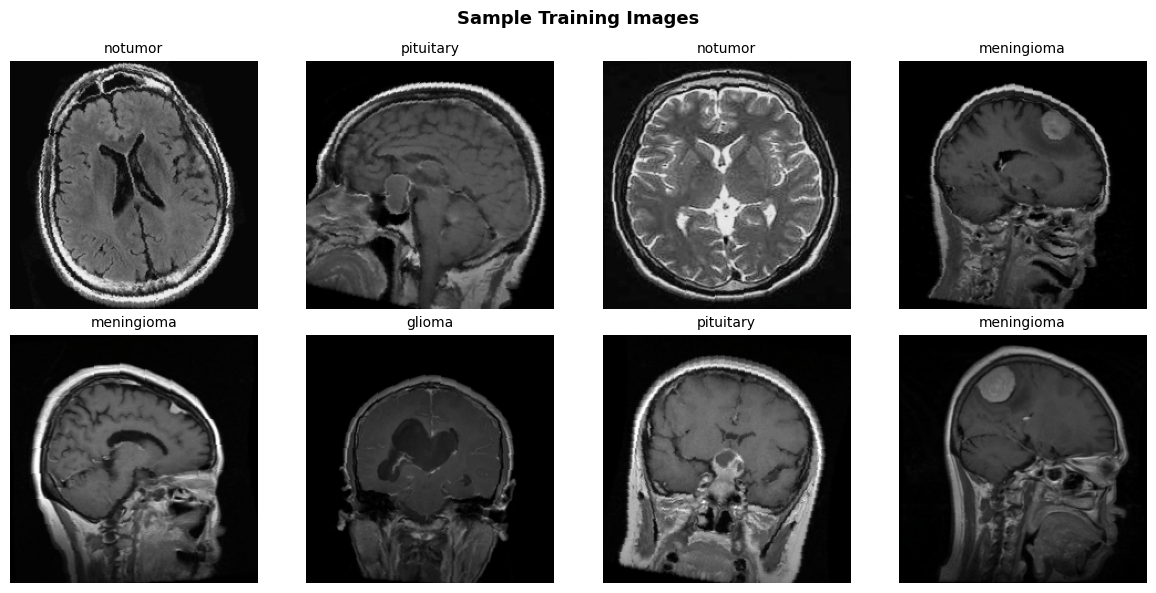

In [5]:
def show_sample_grid(dataset: Dataset, n_cols: int = 4, n_rows: int = 2) -> None:
    '''Display a random grid of images from `dataset` with class labels.'''
    inv_norm = transforms.Normalize(
        mean=[-m / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
        std=[1.0 / s for s in IMAGENET_STD],
    )
    indices = random.sample(range(len(dataset)), n_rows * n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    for ax, idx in zip(axes.flatten(), indices):
        img, label = dataset[idx]
        img = inv_norm(img).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(CLASS_NAMES[label], fontsize=10)
        ax.axis('off')
    plt.suptitle('Sample Training Images', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_sample_grid(train_ds)

---
## **Section 3 — Shared Utilities & Checkpoint Setup**

This section collects everything reused by more than one architectural stage
(CAE, ResNet-50, ViT-B/16), so that any stage can be run independently
without first executing another stage's cells.

**Contents:**
* **Checkpoint cache:** mounts Google Drive and defines `CKPT_DIR`, the
  persistent folder where each stage's best weights + training history are cached.
* **Checkpoint I/O:** `save_checkpoint` / `load_checkpoint` — used by all
  three stages to skip retraining when a cached run already exists.
* **Generic train/eval loop:** `train_one_epoch` / `evaluate` — the standard
  supervised loop used by the CAE classifier head, ResNet-50, and ViT-B/16.
* **Visualization helper:** `denormalize` — reverses ImageNet normalization
  back to `[0, 1]`; reused whenever a stage needs to display original images
  (reconstructions, Grad-CAM overlays, etc.).
* **Diagnostics:** `plot_loss_curve` — plots train/val loss and marks the
  best (lowest val-loss) epoch; called at the end of every stage's training
  cell and again in the final comparison section.

In [6]:
# ── Persistent checkpoint cache on Google Drive ───────────────────────────────
# Mounted here, before any stage, so CAE / ResNet / ViT can each check for a
# cached checkpoint independently of one another.
from google.colab import drive
drive.mount('/content/drive')

CKPT_DIR = Path('/content/drive/MyDrive/brain_tumor_project/checkpoints')
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Checkpoint cache directory: {CKPT_DIR}')


def save_checkpoint(name: str, model: nn.Module, history: dict) -> None:
    '''Persist a model's best weights + training history to Drive.'''
    path = CKPT_DIR / f'{name}.pt'
    torch.save({'model_state': model.state_dict(), 'history': history}, path)
    print(f'  -> saved checkpoint: {path}')


def load_checkpoint(name: str):
    '''Return {"model_state":..., "history":...} if a cached run exists on Drive, else None.'''
    path = CKPT_DIR / f'{name}.pt'
    if path.exists():
        print(f'  -> found cached checkpoint: {path}  (skipping training)')
        return torch.load(path, map_location=device)
    return None

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint cache directory: /content/drive/MyDrive/brain_tumor_project/checkpoints


In [7]:
# ── Shared helper: de-normalise a batch back to [0, 1] ───────────────────────
# Generic and stage-agnostic: any stage that needs to display an original
# image (CAE reconstructions, Grad-CAM overlays, sample grids, ...) can reuse
# this instead of re-deriving its own inverse transform.
def denormalize(t: torch.Tensor) -> torch.Tensor:
    '''Reverse ImageNet normalisation so pixels return to [0, 1].'''
    mean = torch.tensor(IMAGENET_MEAN, device=t.device).view(1, 3, 1, 1)
    std  = torch.tensor(IMAGENET_STD,  device=t.device).view(1, 3, 1, 1)
    return (t * std + mean).clamp(0.0, 1.0)


# ── Generic supervised training / evaluation loop, used by every classifier ──
# (CAE classifier head, ResNet-50, and ViT-B/16 all call these two functions).
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
) -> Tuple[float, float]:
    '''One supervised training epoch. Returns (avg_loss, accuracy).'''
    model.train()
    total_loss = correct = total = 0

    for images, labels in tqdm(loader, leave=False, desc='  train'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Tuple[float, float]:
    '''Evaluate on a dataloader. Returns (avg_loss, accuracy).'''
    model.eval()
    total_loss = correct = total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total


# ── Train vs. validation loss curve (for early-stopping analysis) ────────────
# Called at the end of every stage's training cell, and again in the final
# comparison section (Section 7).
def plot_loss_curve(train_losses: List[float], val_losses: List[float],
                     title: str, ax: Optional[plt.Axes] = None) -> int:
    '''
    Plot train/val loss curves and mark the epoch with the lowest validation
    loss -- i.e. the point where early stopping would have saved/restored
    the best-generalising weights.

    Returns the best epoch (1-indexed) so callers can print/report it.
    '''
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 4.5))

    epochs = range(1, len(train_losses) + 1)
    best_epoch = int(np.argmin(val_losses)) + 1
    best_val   = val_losses[best_epoch - 1]

    ax.plot(epochs, train_losses, label='Train loss', linewidth=2,
            linestyle='--', color='steelblue', alpha=0.8)
    ax.plot(epochs, val_losses, label='Val loss', linewidth=2, color='darkorange')

    ax.axvline(best_epoch, color='gray', linestyle=':', linewidth=1.5)
    ax.scatter([best_epoch], [best_val], color='darkorange', zorder=5,
               edgecolor='black', s=70, marker='*')
    ax.annotate(f'best epoch {best_epoch}',
                xy=(best_epoch, best_val), xytext=(5, 12),
                textcoords='offset points', fontsize=9, color='gray')

    if best_epoch < len(train_losses):
        ax.axvspan(best_epoch, len(train_losses), color='red', alpha=0.06)

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    if standalone:
        plt.tight_layout()
        plt.show()

    return best_epoch

---
## **Section 4 — Base Stage : Convolutional Autoencoder (CAE)**

In this section, we implement a baseline architectural approach leveraging a **two-stage training strategy** to separate feature extraction from classification:

1. **Stage 1 (unsupervised)** — Train Encoder + Decoder end-to-end with MSE reconstruction loss. The encoder learns compact visual features without any labels.
2. **Stage 2 (supervised)** — Freeze the encoder, attach a linear classifier head, and train with Cross-Entropy loss on the 4 classes.

In [8]:
class Encoder(nn.Module):
    '''
    Convolutional Encoder: 3 × 224 × 224  →  latent vector (latent_dim,).

    Spatial resolution is halved four times via MaxPool, producing
    a 256 × 14 × 14 feature volume that is flattened and projected
    to the latent space via a single Linear layer.

    Spatial trace:
        Input      :  3 × 224 × 224
        After block 1:  32 × 112 × 112
        After block 2:  64 ×  56 ×  56
        After block 3: 128 ×  28 ×  28
        After block 4: 256 ×  14 ×  14
        Flat → FC  :   50 176  →  latent_dim
    '''

    def __init__(self, latent_dim: int = 512):
        super().__init__()
        self.latent_dim = latent_dim

        def _block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
            )

        self.conv_blocks = nn.Sequential(
            _block(3,   32),
            _block(32,  64),
            _block(64,  128),
            _block(128, 256),
        )
        self._flat = 256 * 14 * 14   # 50 176
        self.fc    = nn.Linear(self._flat, latent_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_blocks(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class Decoder(nn.Module):
    '''
    Symmetric Convolutional Decoder: latent vector (latent_dim,)  →  3 × 224 × 224.

    Each ConvTranspose2d with stride=2 doubles the spatial dimensions,
    exactly reversing the four MaxPool operations in the Encoder.
    A Sigmoid on the final layer constrains output pixels to [0, 1],
    matching the target range used in the MSE reconstruction loss.
    '''

    def __init__(self, latent_dim: int = 512):
        super().__init__()
        self._flat = 256 * 14 * 14
        self.fc    = nn.Linear(latent_dim, self._flat)

        def _block(in_ch, out_ch, activation=True):
            layers = [
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2, bias=False),
            ]
            if activation:
                layers += [nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
            else:
                layers += [nn.Sigmoid()]
            return nn.Sequential(*layers)

        self.deconv_blocks = nn.Sequential(
            _block(256, 128),
            _block(128, 64),
            _block(64,  32),
            _block(32,  3, activation=False),   # output: 3 × 224 × 224 ∈ [0, 1]
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.fc(z)
        x = x.view(x.size(0), 256, 14, 14)
        return self.deconv_blocks(x)


class ConvAutoencoder(nn.Module):
    '''Full CAE = Encoder + Decoder.  Used during Stage 1 (reconstruction).'''

    def __init__(self, latent_dim: int = 512):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


class CAEClassifier(nn.Module):
    '''
    Classification head attached to a (frozen) Encoder.
    Used during Stage 2 (supervised fine-tuning).

    By default (hidden_dim=None) this is a pure linear probe: Dropout ->
    Linear(latent_dim, num_classes) -- exactly the main Stage 2 experiment.
    Passing hidden_dim turns it into a 2-layer MLP probe (Dropout -> Linear
    -> ReLU -> Dropout -> Linear); this is used only for the Stage 2b
    capacity-check ablation, to see how much of the CAE branch's accuracy
    gap is due to the *head's* limited capacity rather than the frozen
    representation itself not being linearly separable.
    '''

    def __init__(self, encoder: Encoder, num_classes: int = 4, dropout: float = 0.4, hidden_dim: Optional[int] = None):
        super().__init__()
        self.encoder    = encoder
        if hidden_dim is None:
          # Linear probe
          self.classifier = nn.Sequential(
              nn.Dropout(dropout),
              nn.Linear(encoder.latent_dim, num_classes)
          )
        else:
          # 2-layer MLP probe
          self.classifier = nn.Sequential(
              nn.Dropout(dropout),
              nn.Linear(encoder.latent_dim, hidden_dim),
              nn.ReLU(inplace=True),
              nn.Dropout(dropout),
              nn.Linear(hidden_dim, num_classes)
          )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        return self.classifier(z)


# ── Quick parameter count ─────────────────────────────────────────────────────
LATENT_DIM = 512
_tmp_cae   = ConvAutoencoder(LATENT_DIM)
print(f'CAE total parameters: {sum(p.numel() for p in _tmp_cae.parameters()):,}')
del _tmp_cae

CAE total parameters: 51,992,672


In [9]:
# ── CAE-specific: unsupervised (optionally denoising) autoencoder epoch ────
# Denoising variant: the encoder sees a noise-corrupted input, but the
# reconstruction target is still the clean (augmented) image. This forces
# the bottleneck to encode robust, semantic structure rather than being
# able to "cheat" by passing pixel-level noise straight through.


def train_ae_epoch(
    model: ConvAutoencoder,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    noise_std: float = 0.0,
) -> float:
    '''One unsupervised (optionally denoising) autoencoder epoch.  Returns avg MSE loss.'''
    model.train()
    total_loss = total = 0

    for images, _ in tqdm(loader, leave=False, desc='  AE train'):
        images = images.to(device)
        optimizer.zero_grad()

        # Clean reconstruction target, computed BEFORE any corruption.
        target = denormalize(images)

        # Corrupt only the encoder's input (denoising objective); target
        # stays clean, so the model must learn to "undo" the noise.
        encoder_input = images
        if noise_std > 0:
            encoder_input = images + noise_std * torch.randn_like(images)

        recon, _ = model(encoder_input)
        loss     = criterion(recon, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total      += images.size(0)

    return total_loss / total


def evaluate_ae_epoch(
    model: ConvAutoencoder,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    '''One unsupervised evaluation epoch: clean reconstruction, no noise, no gradient.
    Returns avg MSE loss on `loader` (used with val_loader for early stopping).'''
    model.eval()
    total_loss = total = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            target = denormalize(images)          # clean target
            recon, _ = model(images)               # clean input, no noise injected
            loss = criterion(recon, target)

            total_loss += loss.item() * images.size(0)
            total      += images.size(0)

    return total_loss / total

**CAMBIAMENTO**

`CAE_LR`: from 1e-3 to 2e-3

in `ae_scheduler`: `factor`=0.5 -> 0.3 and `patience`=2 -> 1

  -> found cached checkpoint: /content/drive/MyDrive/brain_tumor_project/checkpoints/cae_stage1_denoise.pt  (skipping training)
Best AE MSE Loss (cached): 0.005775


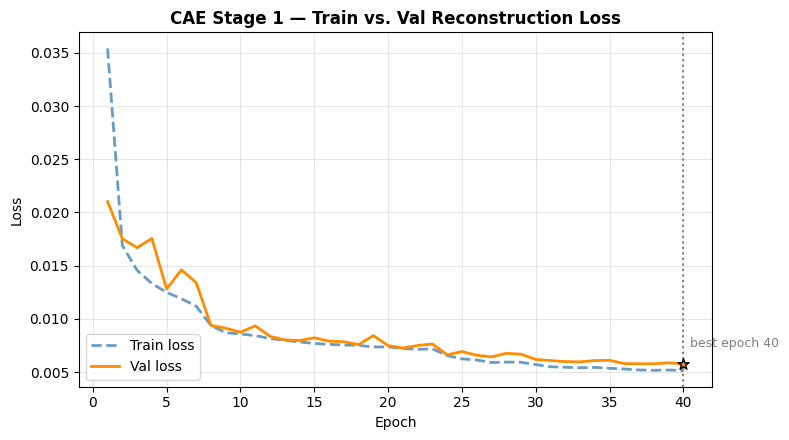

Lowest val-loss epoch: 40  -> encoder weights reloaded from there.


In [10]:
# ── Stage 1: Unsupervised Denoising Autoencoder Training ────────────────────────────────
CAE_EPOCHS  = 40
CAE_LR      = 2e-3
AE_NOISE_STD = 0.15
PATIENCE = 5 #This tells to the early stopping to stop if it hasn't improved in 5 epochs

FORCE_RETRAIN_CAE_STAGE1 = False #Forces to skip the checkpoints and retrain from scratch if True (DEBUG PURPOSES)

cae_model = ConvAutoencoder(LATENT_DIM).to(device)
cached    = None if FORCE_RETRAIN_CAE_STAGE1 else load_checkpoint('cae_stage1_denoise')

if cached is not None:
    cae_model.load_state_dict(cached['model_state'])
    cae_losses = cached['history']['cae_losses']
    cae_val_ae_losses = cached['history']['cae_val_ae_losses']
    best_ae_loss = cached['history']['best_ae_loss']
    print(f'Best AE MSE Loss (cached): {best_ae_loss:.6f}')
else:
    ae_criterion = nn.MSELoss()
    ae_optimizer = optim.Adam(cae_model.parameters(), lr=CAE_LR, weight_decay=1e-5)
    # Tied to the actual training-loss plateau, instead of a fixed step
    # schedule: the previous StepLR(step_size=10) decayed on a fixed clock
    # regardless of whether the loss had actually stalled, and in the
    # original run the loss was still falling steadily at epoch 25 with no
    # plateau in sight. ReduceLROnPlateau only cuts the LR once improvement
    # genuinely stalls for `patience` epochs.
    ae_scheduler = optim.lr_scheduler.ReduceLROnPlateau(ae_optimizer, mode='min', factor=0.3, patience=1, min_lr=1e-6)

    cae_losses = []
    cae_val_ae_losses = []
    best_ae_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(1, CAE_EPOCHS + 1):
        loss     = train_ae_epoch(cae_model, train_loader, ae_criterion, ae_optimizer, device, noise_std=AE_NOISE_STD)
        val_loss = evaluate_ae_epoch(cae_model, val_loader, ae_criterion, device)
        ae_scheduler.step(val_loss)   # ReduceLROnPlateau needs a metric to watch
        cae_losses.append(loss)
        cae_val_ae_losses.append(val_loss)
        current_lr = ae_optimizer.param_groups[0]['lr']

        print(f'[AE Stage 1]  Epoch {epoch:3d}/{CAE_EPOCHS}  |  Train MSE: {loss:.6f}  |'
              f'  Val MSE: {val_loss:.6f}  |  LR: {current_lr:.2e}')

        if val_loss < best_ae_loss:
          best_ae_loss = val_loss
          epochs_no_improve = 0
          torch.save(cae_model.state_dict(), '/content/best_cae.pth')
        else:
          epochs_no_improve += 1
          if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}, no val-loss improvement in {PATIENCE} epochs.")
            break

    print(f'\nBest AE Val MSE Loss: {best_ae_loss:.6f}')

    # Reload the best (lowest VAL-loss) epoch's weights before handing the encoder to Stage 2
    cae_model.load_state_dict(torch.load('/content/best_cae.pth', map_location=device))
    save_checkpoint('cae_stage1_denoise', cae_model,
                     {'cae_losses': cae_losses, 'cae_val_ae_losses': cae_val_ae_losses,
                      'best_ae_loss': best_ae_loss})

cae_stage1_best_epoch = plot_loss_curve(cae_losses, cae_val_ae_losses,
                                         'CAE Stage 1 — Train vs. Val Reconstruction Loss')
print(f'Lowest val-loss epoch: {cae_stage1_best_epoch}  -> encoder weights reloaded from there.')

With a raised base LR and a `ReduceLROnPlateau` that cuts both faster (`patience=1`) and more aggressively (`factor=0.3`), bigger steps early on cover the loss landscape faster, while quicker, steeper LR cuts let it settle in sooner instead of drifting on a plateau. Early stopping never actually triggered in this run, but the LR had already decayed to near-zero by ~epoch 36.

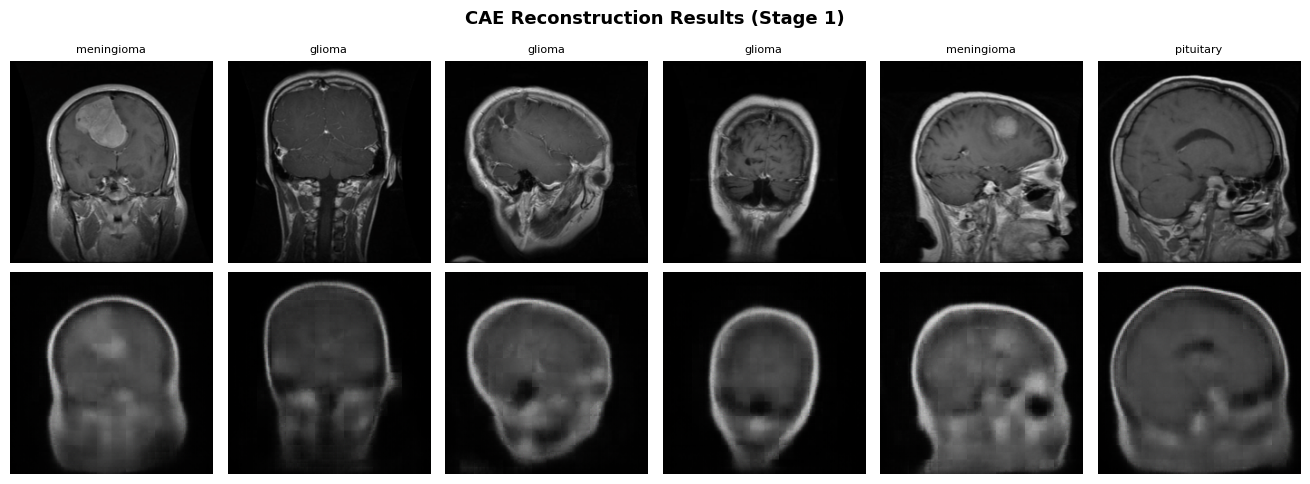

In [11]:
def visualize_reconstructions(
    model: ConvAutoencoder,
    loader: DataLoader,
    device: torch.device,
    n: int = 6,
) -> None:
    '''Side-by-side display of original MRI scans and their reconstructions.'''
    model.eval()
    images, labels = next(iter(loader))
    images = images[:n].to(device)

    with torch.no_grad():
        recon, _ = model(images)

    originals = denormalize(images).cpu().permute(0, 2, 3, 1).numpy()
    recons    = recon.cpu().clamp(0, 1).permute(0, 2, 3, 1).numpy()
    label_ids = labels[:n].tolist()

    fig, axes = plt.subplots(2, n, figsize=(n * 2.2, 5))
    for i in range(n):
        axes[0, i].imshow(originals[i])
        axes[0, i].set_title(CLASS_NAMES[label_ids[i]], fontsize=8)
        axes[0, i].axis('off')
        axes[1, i].imshow(recons[i])
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=11)
    axes[1, 0].set_ylabel('Reconstructed', fontsize=11)
    plt.suptitle('CAE Reconstruction Results (Stage 1)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# cae_model already holds its best (lowest reconstruction-loss) weights here --
# either freshly trained-and-reloaded, or restored straight from the Drive cache.
visualize_reconstructions(cae_model, val_loader, device)

Trainable parameters (head only): 2,052
  -> found cached checkpoint: /content/drive/MyDrive/brain_tumor_project/checkpoints/cae_stage2.pt  (skipping training)
Best CAE classifier Val Accuracy (cached): 0.8036


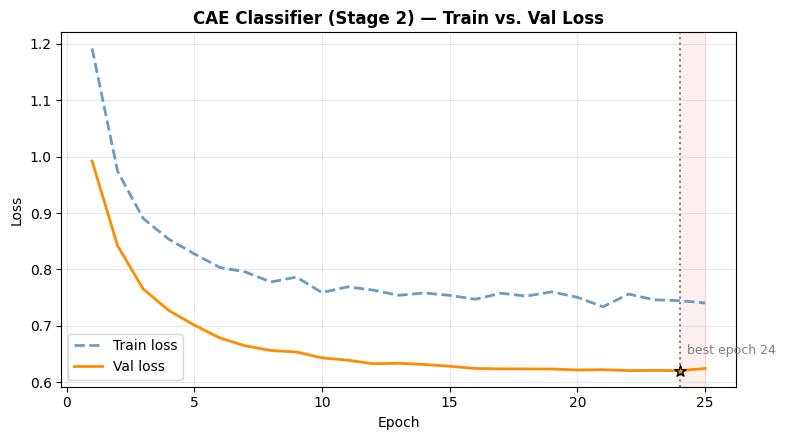

Lowest val loss at epoch 24/25 -> early stopping here would have kept the best-generalising weights.


In [12]:
# ── Stage 2: Supervised Classification with Frozen Encoder ───────────────────

CLS_EPOCHS = 25
CLS_LR     = 1e-3
PATIENCE = 5

FORCE_RETRAIN_CAE_STAGE2 = False

cae_classifier = CAEClassifier(cae_model.encoder, num_classes=NUM_CLASSES).to(device)

# Freeze encoder — only the 2-layer head will receive gradient updates
for param in cae_classifier.encoder.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in cae_classifier.parameters() if p.requires_grad)
print(f'Trainable parameters (head only): {trainable:,}')

cached = None if FORCE_RETRAIN_CAE_STAGE2 else load_checkpoint('cae_stage2')

if cached is not None:
    cae_classifier.load_state_dict(cached['model_state'])
    h = cached['history']
    cae_train_accs, cae_val_accs     = h['train_accs'], h['val_accs']
    cae_train_losses, cae_val_losses = h['train_losses'], h['val_losses']
    best_cae_val_acc                 = h['best_val_acc']
    print(f'Best CAE classifier Val Accuracy (cached): {best_cae_val_acc:.4f}')
else:
    cls_criterion = nn.CrossEntropyLoss()
    cls_optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, cae_classifier.parameters()),
        lr=CLS_LR,
    )
    cls_scheduler = optim.lr_scheduler.CosineAnnealingLR(cls_optimizer, T_max=CLS_EPOCHS)

    cae_train_accs, cae_val_accs = [], []
    cae_train_losses, cae_val_losses = [], []
    best_cae_val_acc = 0.0
    best_val_loss = float('inf')

    for epoch in range(1, CLS_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(cae_classifier, train_loader,
                                           cls_criterion, cls_optimizer, device)
        vl_loss, vl_acc = evaluate(cae_classifier, val_loader, cls_criterion, device)
        cls_scheduler.step()

        cae_train_accs.append(tr_acc)
        cae_val_accs.append(vl_acc)
        cae_train_losses.append(tr_loss)
        cae_val_losses.append(vl_loss)
        print(f'[CAE Stage 2]  Epoch {epoch:3d}/{CLS_EPOCHS}  |'
              f'  Train Accuracy {tr_acc:.4f}  Val Accuracy {vl_acc:.4f}  Val Loss {vl_loss:.4f}');

        if vl_loss < best_val_loss:
          best_val_loss = vl_loss
          best_cae_val_acc = vl_acc
          epochs_no_improve = 0
          torch.save(cae_classifier.state_dict(), '/content/best_cae_cls.pth')
        else:
          epochs_no_improve += 1
          if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}, no val-loss improvement in {PATIENCE} epochs.")
            break


    print(f'\nBest CAE classifier Val Accuracy: {best_cae_val_acc:.4f}')

    # Reload the best (highest val-acc) epoch's weights before caching/evaluating
    cae_classifier.load_state_dict(torch.load('/content/best_cae_cls.pth', map_location=device))
    save_checkpoint('cae_stage2', cae_classifier, {
        'train_accs': cae_train_accs, 'val_accs': cae_val_accs,
        'train_losses': cae_train_losses, 'val_losses': cae_val_losses,
        'best_val_acc': best_cae_val_acc,
    })

cae_best_epoch = plot_loss_curve(cae_train_losses, cae_val_losses,
                                  'CAE Classifier (Stage 2) — Train vs. Val Loss')
print(f'Lowest val loss at epoch {cae_best_epoch}/{CLS_EPOCHS} '
      '-> early stopping here would have kept the best-generalising weights.')

Trainable parameters (MLP head): 132,356  (vs. 2,052 for the linear head above)
  -> found cached checkpoint: /content/drive/MyDrive/brain_tumor_project/checkpoints/cae_stage2_mlp.pt  (skipping training)
Best CAE MLP-head Val Accuracy (cached): 0.8929


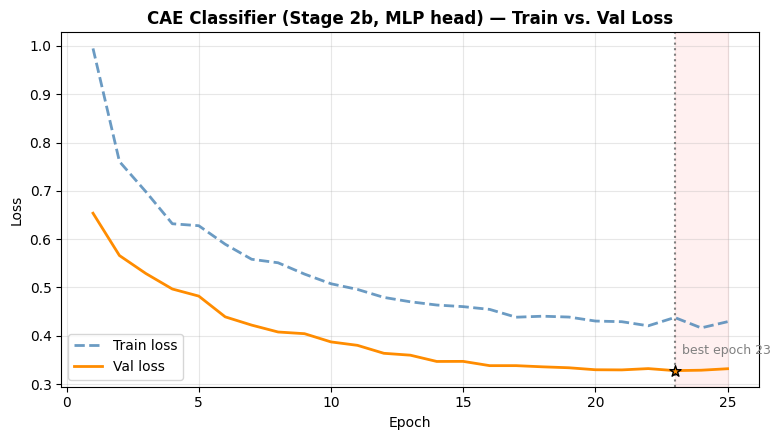

Lowest val loss at epoch 23/25

Linear-head val accuracy : 0.8036
MLP-head val accuracy    : 0.8929
Delta (MLP - Linear)     : +0.0893


In [13]:
# ── Stage 2b: MLP-head ablation (same frozen encoder, deeper probe) ─────────
# Identical to Stage 2 above (same frozen encoder, same data, same
# optimizer/scheduler recipe) except the classification head now has one
# hidden layer instead of being purely linear. This isolates how much of
# the CAE branch's accuracy gap is due to the *head's* limited capacity, as
# opposed to the frozen representation itself not being linearly separable.
# This is an ablation, not a replacement: the Stage 2 linear-probe result
# above remains the main reported CAE result.

MLP_HIDDEN_DIM = 256
PATIENCE = 5

FORCE_RETRAIN_CAE_STAGE2B = False

cae_classifier_mlp = CAEClassifier(cae_model.encoder, num_classes=NUM_CLASSES,
                                    hidden_dim=MLP_HIDDEN_DIM).to(device)

for param in cae_classifier_mlp.encoder.parameters():
    param.requires_grad = False

trainable_mlp = sum(p.numel() for p in cae_classifier_mlp.parameters() if p.requires_grad)
print(f'Trainable parameters (MLP head): {trainable_mlp:,}  (vs. 2,052 for the linear head above)')

cached = None if FORCE_RETRAIN_CAE_STAGE2B else load_checkpoint('cae_stage2_mlp')

if cached is not None:
    cae_classifier_mlp.load_state_dict(cached['model_state'])
    h = cached['history']
    mlp_train_accs, mlp_val_accs     = h['train_accs'], h['val_accs']
    mlp_train_losses, mlp_val_losses = h['train_losses'], h['val_losses']
    best_mlp_val_acc                 = h['best_val_acc']
    print(f'Best CAE MLP-head Val Accuracy (cached): {best_mlp_val_acc:.4f}')
else:
    cls_criterion = nn.CrossEntropyLoss()
    cls_optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, cae_classifier_mlp.parameters()),
        lr=CLS_LR,
    )
    cls_scheduler = optim.lr_scheduler.CosineAnnealingLR(cls_optimizer, T_max=CLS_EPOCHS)

    mlp_train_accs, mlp_val_accs = [], []
    mlp_train_losses, mlp_val_losses = [], []
    best_mlp_val_acc = 0.0
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(1, CLS_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(cae_classifier_mlp, train_loader,
                                           cls_criterion, cls_optimizer, device)
        vl_loss, vl_acc = evaluate(cae_classifier_mlp, val_loader, cls_criterion, device)
        cls_scheduler.step()

        mlp_train_accs.append(tr_acc)
        mlp_val_accs.append(vl_acc)
        mlp_train_losses.append(tr_loss)
        mlp_val_losses.append(vl_loss)
        print(f'[CAE Stage 2b/MLP]  Epoch {epoch:3d}/{CLS_EPOCHS}  |'
              f'  Train Accuracy {tr_acc:.4f}  Val Accuracy {vl_acc:.4f}  Val Loss {vl_loss:.4f}')

        if vl_loss < best_val_loss:
          best_val_loss = vl_loss
          best_mlp_val_acc = vl_acc
          epochs_no_improve = 0
          torch.save(cae_classifier_mlp.state_dict(), '/content/best_cae_cls_mlp.pth')
        else:
          epochs_no_improve += 1
          if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}, no val-loss improvement in {PATIENCE} epochs.")
            break

    print(f'\nBest CAE MLP-head Val Accuracy: {best_mlp_val_acc:.4f}')

    cae_classifier_mlp.load_state_dict(torch.load('/content/best_cae_cls_mlp.pth', map_location=device))
    save_checkpoint('cae_stage2_mlp', cae_classifier_mlp, {
        'train_accs': mlp_train_accs, 'val_accs': mlp_val_accs,
        'train_losses': mlp_train_losses, 'val_losses': mlp_val_losses,
        'best_val_acc': best_mlp_val_acc,
    })

mlp_best_epoch = plot_loss_curve(mlp_train_losses, mlp_val_losses,
                                  'CAE Classifier (Stage 2b, MLP head) — Train vs. Val Loss')
print(f'Lowest val loss at epoch {mlp_best_epoch}/{CLS_EPOCHS}')
print(f'\nLinear-head val accuracy : {best_cae_val_acc:.4f}')
print(f'MLP-head val accuracy    : {best_mlp_val_acc:.4f}')
print(f'Delta (MLP - Linear)     : {best_mlp_val_acc - best_cae_val_acc:+.4f}')

**RESULTS**

linear-head had a worst result; MLP a better one.

SO, since the Stage 1 reconstruction loss did clearly improve, and no result got meaningfully worse, we can think of keeping the new Stage 1 settings.

We understand that making the autoencoder better at reconstructing images doesn't necessarily make it better at helping classify tumors: the two goals aren't the same thing!

ALSO, classes aren't linearly separable, hence MLP > linear

**TO THINK**: as CAE should work as a baseline, is good to keep previous setup to show a worst result and so to enhance next results? claude says no in order to be honest!

---
## **Section 5 — Intermediate Stage: ResNet-50 Fine-Tuning & Grad-CAM**

In this stage, we introduce deep transfer learning combined with post-hoc explainability to classify our MRI scans and visually validate our network's decision-making process.

* **ResNet-50** is fully fine-tuned (all layers trainable) with its classification head replaced by a 4-class output.

* **Grad-CAM** (Selvaraju et al., ICCV 2017) identifies *which spatial regions* drove a prediction by:
  1. Capturing feature maps $A^k$ at the last conv layer (`layer4[-1]`).
  2. Computing channel weights $\alpha_k = \frac{1}{Z}\sum_{i,j} \frac{\partial y^c}{\partial A^k_{ij}}$ via global-average-pooled gradients.
  3. Forming the heatmap $L^c = \text{ReLU}\!\left(\sum_k \alpha_k A^k\right)$.

In [18]:
class ResNet50Classifier(nn.Module):
    '''
    Pre-trained ResNet-50 adapted for 4-class brain tumour classification.

    The final fully-connected layer (2048 → 1000) is replaced with
    Dropout → Linear(2048, num_classes).  All layers remain trainable
    (full fine-tuning), which outperforms head-only tuning when the
    target domain (medical imaging) differs from ImageNet.
    '''

    def __init__(self, num_classes: int = 4, dropout: float = 0.4, pretrained: bool = True):
        super().__init__()
        weights        = models.ResNet50_Weights.IMAGENET1K_V1
        backbone       = models.resnet50(weights=weights)
        in_features    = backbone.fc.in_features           # 2048
        backbone.fc    = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )
        self.model = backbone

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

**CASE 1: PRE-TRAINED ResNet**

Here we use the pretrained ResNet-50 (ImageNet weights), fully fine-tuned
end-to-end with a conservative learning rate (1e-4) that preserves the
pretrained low-level features while adapting the network to our MRI
domain. This is our primary Stage 2 model, used for the main comparison
against the CAE and ViT branches.

In [20]:
# ── CASE 1: instantiate the pretrained ResNet-50 ─────────────────────────────
resnet_model_pretrained = ResNet50Classifier(NUM_CLASSES, pretrained=True).to(device)
total_rn = sum(p.numel() for p in resnet_model_pretrained.parameters())
print(f'ResNet-50 (pretrained) parameters: {total_rn:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 76.0MB/s]


ResNet-50 (pretrained) parameters: 23,516,228


Trainable parameters: 23,290,884  (frozen: 225,344)


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ResNet-50 pretrained]  Epoch   1/20  |  Train 0.9054  Val 0.9500


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ResNet-50 pretrained]  Epoch   2/20  |  Train 0.9580  Val 0.9696


...

[ResNet-50 pretrained]  Epoch  17/20  |  Train 0.9989  Val 0.9857


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ResNet-50 pretrained]  Epoch  18/20  |  Train 0.9991  Val 0.9857


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ResNet-50 pretrained]  Epoch  19/20  |  Train 0.9980  Val 0.9857
Early stopping at epoch 19, no val-loss improvement in 5 epochs.

Best ResNet-50 (pretrained) Val Accuracy: 0.9893
  -> saved checkpoint: /content/drive/MyDrive/brain_tumor_project/checkpoints/resnet50_pretrained.pt


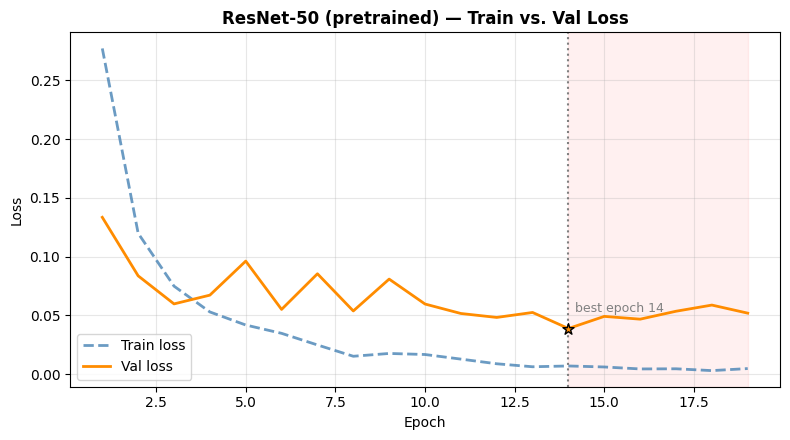

Lowest val loss at epoch 14/20 -> early stopping here would have kept the best-generalising weights.


In [22]:
RN_EPOCHS = 20
RN_LR     = 1e-4    # conservative LR preserves pre-trained ImageNet features
PATIENCE  = 5

FORCE_RETRAIN_RESNET_PRETRAINED = True

cached = None if FORCE_RETRAIN_RESNET_PRETRAINED else load_checkpoint('resnet50_pretrained')

if cached is not None:
    resnet_model_pretrained.load_state_dict(cached['model_state'])
    h = cached['history']
    rn_train_accs, rn_val_accs     = h['train_accs'], h['val_accs']
    rn_train_losses, rn_val_losses = h['train_losses'], h['val_losses']
    best_rn_val_acc                = h['best_val_acc']
    print(f'Best ResNet-50 (pretrained) Val Accuracy (cached): {best_rn_val_acc:.4f}')
else:
    backbone = resnet_model_pretrained.model

    # ── Freeze the earliest, most generic feature layers ────────────────────
    # Low-level edge/texture filters learned on ImageNet rarely need to move
    # for a medical-imaging task, and freezing them cuts the number of
    # trainable parameters, which helps against the overfitting visible in
    # the original run (train acc. 99.75% by epoch 9 vs. ~98% val / 94.9% test).
    for layer in (backbone.conv1, backbone.bn1, backbone.layer1):
        for param in layer.parameters():
            param.requires_grad = False

    # ── Discriminative (layer-wise) learning rates for the rest ─────────────
    param_groups = [
        {'params': backbone.layer2.parameters(), 'lr': RN_LR / 10},
        {'params': backbone.layer3.parameters(), 'lr': RN_LR / 3},
        {'params': backbone.layer4.parameters(), 'lr': RN_LR},
        {'params': backbone.fc.parameters(),     'lr': RN_LR},
    ]

    trainable_rn = sum(p.numel() for p in resnet_model_pretrained.parameters() if p.requires_grad)
    frozen_rn    = sum(p.numel() for p in resnet_model_pretrained.parameters() if not p.requires_grad)
    print(f'Trainable parameters: {trainable_rn:,}  (frozen: {frozen_rn:,})')

    rn_criterion = nn.CrossEntropyLoss()
    rn_optimizer = optim.AdamW(param_groups, weight_decay=1e-5)
    rn_scheduler = optim.lr_scheduler.CosineAnnealingLR(rn_optimizer, T_max=RN_EPOCHS)

    rn_train_accs, rn_val_accs = [], []
    rn_train_losses, rn_val_losses = [], []
    best_rn_val_acc = 0.0
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(1, RN_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(resnet_model_pretrained, train_loader, rn_criterion, rn_optimizer, device)
        vl_loss, vl_acc = evaluate(resnet_model_pretrained, val_loader, rn_criterion, device)
        rn_scheduler.step()

        rn_train_accs.append(tr_acc); rn_val_accs.append(vl_acc)
        rn_train_losses.append(tr_loss); rn_val_losses.append(vl_loss)
        print(f'[ResNet-50 pretrained]  Epoch {epoch:3d}/{RN_EPOCHS}  |  Train {tr_acc:.4f}  Val {vl_acc:.4f}')

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_rn_val_acc = vl_acc
            epochs_no_improve = 0
            torch.save(resnet_model_pretrained.state_dict(), '/content/best_resnet50_pretrained.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch}, no val-loss improvement in {PATIENCE} epochs.")
                break

    print(f'\nBest ResNet-50 (pretrained) Val Accuracy: {best_rn_val_acc:.4f}')
    resnet_model_pretrained.load_state_dict(torch.load('/content/best_resnet50_pretrained.pth', map_location=device))
    save_checkpoint('resnet50_pretrained', resnet_model_pretrained, {
        'train_accs': rn_train_accs, 'val_accs': rn_val_accs,
        'train_losses': rn_train_losses, 'val_losses': rn_val_losses,
        'best_val_acc': best_rn_val_acc,
    })

rn_best_epoch = plot_loss_curve(rn_train_losses, rn_val_losses, 'ResNet-50 (pretrained) — Train vs. Val Loss')
print(f'Lowest val loss at epoch {rn_best_epoch}/{RN_EPOCHS} -> early stopping here would have kept the best-generalising weights.')

**CASE 2: ResNet FROM SCRATCH**

Here we train the same ResNet-50 architecture from randomly initialized
weights (no ImageNet pretraining), using a higher learning rate (1e-3)
and a longer training budget (30 vs. 20 epochs) to compensate for slower
convergence without a pretrained starting point. This is not meant to
outperform Case 1 — it's an ablation to quantify how much of our Stage 2
performance comes from ImageNet pretraining versus the architecture
itself, given our relatively small training set (4,480 images).

In [23]:
# ── CASE 2: instantiate ResNet-50 from scratch (no ImageNet weights) ────────
resnet_model_scratch = ResNet50Classifier(NUM_CLASSES, pretrained=False).to(device)
total_rn_scratch = sum(p.numel() for p in resnet_model_scratch.parameters())
print(f'ResNet-50 (scratch) parameters: {total_rn_scratch:,}')

ResNet-50 (scratch) parameters: 23,516,228


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ResNet-50 scratch]  Epoch   1/30  |  Train 0.8310  Val 0.7464


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ResNet-50 scratch]  Epoch   2/30  |  Train 0.8844  Val 0.7518


  train:   0%|          | 0/140 [00:00<?, ?it/s]

...

[ResNet-50 scratch]  Epoch  25/30  |  Train 0.9980  Val 0.9839


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ResNet-50 scratch]  Epoch  26/30  |  Train 0.9978  Val 0.9839


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ResNet-50 scratch]  Epoch  27/30  |  Train 0.9978  Val 0.9875
Early stopping at epoch 27, no val-loss improvement in 5 epochs.

Best ResNet-50 (scratch) Val Accuracy: 0.9804
  -> saved checkpoint: /content/drive/MyDrive/brain_tumor_project/checkpoints/resnet50_scratch.pt


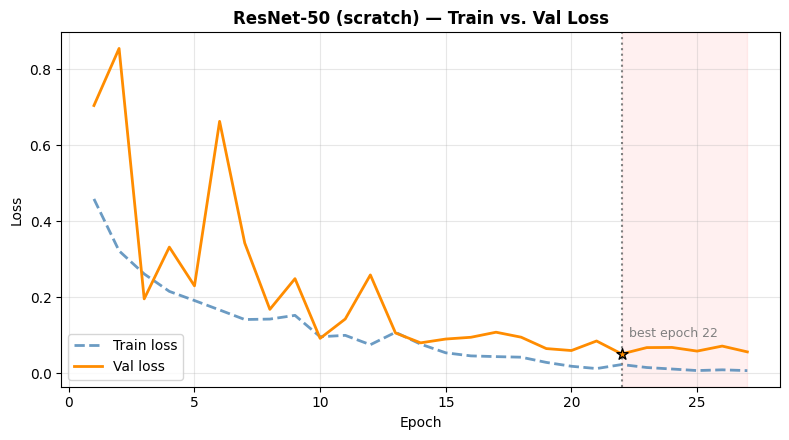

Lowest val loss at epoch 22/30 -> early stopping here would have kept the best-generalising weights.


In [24]:
RNS_EPOCHS = 30      # slower convergence without pretrained features — more room
RNS_LR     = 1e-3    # higher: no pretrained features to protect, random init needs a bigger step
PATIENCE   = 5

FORCE_RETRAIN_RESNET_SCRATCH = True

cached = None if FORCE_RETRAIN_RESNET_SCRATCH else load_checkpoint('resnet50_scratch')

if cached is not None:
    resnet_model_scratch.load_state_dict(cached['model_state'])
    h = cached['history']
    rns_train_accs, rns_val_accs     = h['train_accs'], h['val_accs']
    rns_train_losses, rns_val_losses = h['train_losses'], h['val_losses']
    best_rns_val_acc                 = h['best_val_acc']
    print(f'Best ResNet-50 (scratch) Val Accuracy (cached): {best_rns_val_acc:.4f}')
else:
    # No freezing, no discriminative LR groups: unlike Case 1, there are no
    # pretrained features to preserve, so every parameter trains together.
    rns_criterion = nn.CrossEntropyLoss()
    rns_optimizer = optim.Adam(resnet_model_scratch.parameters(), lr=RNS_LR, weight_decay=1e-5)
    rns_scheduler = optim.lr_scheduler.CosineAnnealingLR(rns_optimizer, T_max=RNS_EPOCHS)

    rns_train_accs, rns_val_accs = [], []
    rns_train_losses, rns_val_losses = [], []
    best_rns_val_acc = 0.0
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(1, RNS_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(resnet_model_scratch, train_loader, rns_criterion, rns_optimizer, device)
        vl_loss, vl_acc = evaluate(resnet_model_scratch, val_loader, rns_criterion, device)
        rns_scheduler.step()

        rns_train_accs.append(tr_acc); rns_val_accs.append(vl_acc)
        rns_train_losses.append(tr_loss); rns_val_losses.append(vl_loss)
        print(f'[ResNet-50 scratch]  Epoch {epoch:3d}/{RNS_EPOCHS}  |  Train {tr_acc:.4f}  Val {vl_acc:.4f}')

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_rns_val_acc = vl_acc
            epochs_no_improve = 0
            torch.save(resnet_model_scratch.state_dict(), '/content/best_resnet50_scratch.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch}, no val-loss improvement in {PATIENCE} epochs.")
                break

    print(f'\nBest ResNet-50 (scratch) Val Accuracy: {best_rns_val_acc:.4f}')
    resnet_model_scratch.load_state_dict(torch.load('/content/best_resnet50_scratch.pth', map_location=device))
    save_checkpoint('resnet50_scratch', resnet_model_scratch, {
        'train_accs': rns_train_accs, 'val_accs': rns_val_accs,
        'train_losses': rns_train_losses, 'val_losses': rns_val_losses,
        'best_val_acc': best_rns_val_acc,
    })

rns_best_epoch = plot_loss_curve(rns_train_losses, rns_val_losses, 'ResNet-50 (scratch) — Train vs. Val Loss')
print(f'Lowest val loss at epoch {rns_best_epoch}/{RNS_EPOCHS} -> early stopping here would have kept the best-generalising weights.')

**Why Grad-CAM only on the pretrained ResNet**

Grad-CAM is applied only to the pretrained, fully fine-tuned ResNet-50
(Case 1), not to the from-scratch version (Case 2). Case 2 exists solely
to quantify the contribution of ImageNet pretraining through its final
test accuracy; it is not part of our primary model comparison, so
visualizing its attention maps would not add evidence toward that
specific question. Grad-CAM is instead reserved for the model we
actually report and discuss as our Stage 2 result.

In [25]:
class GradCAM:
    '''
    Gradient-weighted Class Activation Mapping (Grad-CAM).

    Registers a forward hook to capture feature-map activations and a
    backward hook to capture the corresponding gradients at the chosen
    `target_layer`.  After a forward + backward pass the heatmap is
    computed as:

        alpha_k = mean over (i, j) of  d(score_c) / d(A_k_ij)
        L_c     = ReLU( sum_k  alpha_k * A_k )

    The ReLU discards channels with a negative contribution, leaving
    only regions that positively activated the predicted class.

    Args:
        model        : PyTorch model to inspect.
        target_layer : The nn.Module to hook (e.g. resnet.model.layer4[-1]).
    '''

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model        = model
        self._activations : Optional[torch.Tensor] = None
        self._gradients   : Optional[torch.Tensor] = None

        # Forward hook: stores the output (activations) of target_layer
        def _fwd_hook(module, inp, out):
            self._activations = out.detach()   # shape: (B, C, H, W)

        # Backward hook: stores the gradient flowing back through target_layer
        def _bwd_hook(module, grad_in, grad_out):
            self._gradients = grad_out[0].detach()  # shape: (B, C, H, W)

        self._fwd_handle = target_layer.register_forward_hook(_fwd_hook)
        self._bwd_handle = target_layer.register_full_backward_hook(_bwd_hook)

    def compute(
        self,
        input_tensor: torch.Tensor,          # (1, C, H, W)
        class_idx: Optional[int] = None,
    ) -> np.ndarray:
        '''
        Return a normalised Grad-CAM heatmap as a (H_feat, W_feat) ndarray.

        If `class_idx` is None the top-predicted class is used.
        '''
        self.model.eval()
        dev = next(self.model.parameters()).device
        inp = input_tensor.to(dev)

        # --- Forward pass (hooks capture activations) ---
        logits = self.model(inp)              # (1, num_classes)
        if class_idx is None:
            class_idx = int(logits.argmax(1).item())

        # --- Backward pass (hooks capture gradients) ---
        self.model.zero_grad()
        logits[0, class_idx].backward()

        # --- Grad-CAM formula ---
        grads = self._gradients[0]            # (C, H, W)
        acts  = self._activations[0]          # (C, H, W)

        # Global-average-pool the gradients per channel → scalar importance weight
        weights = grads.mean(dim=(1, 2))      # (C,)

        # Weighted linear combination of activation maps
        cam = torch.einsum('c,chw->hw', weights, acts)
        cam = F.relu(cam)                     # discard negatively-contributing regions

        # Normalise to [0, 1]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy()

    def remove_hooks(self) -> None:
        '''Remove hooks to free memory when Grad-CAM is no longer needed.'''
        self._fwd_handle.remove()
        self._bwd_handle.remove()

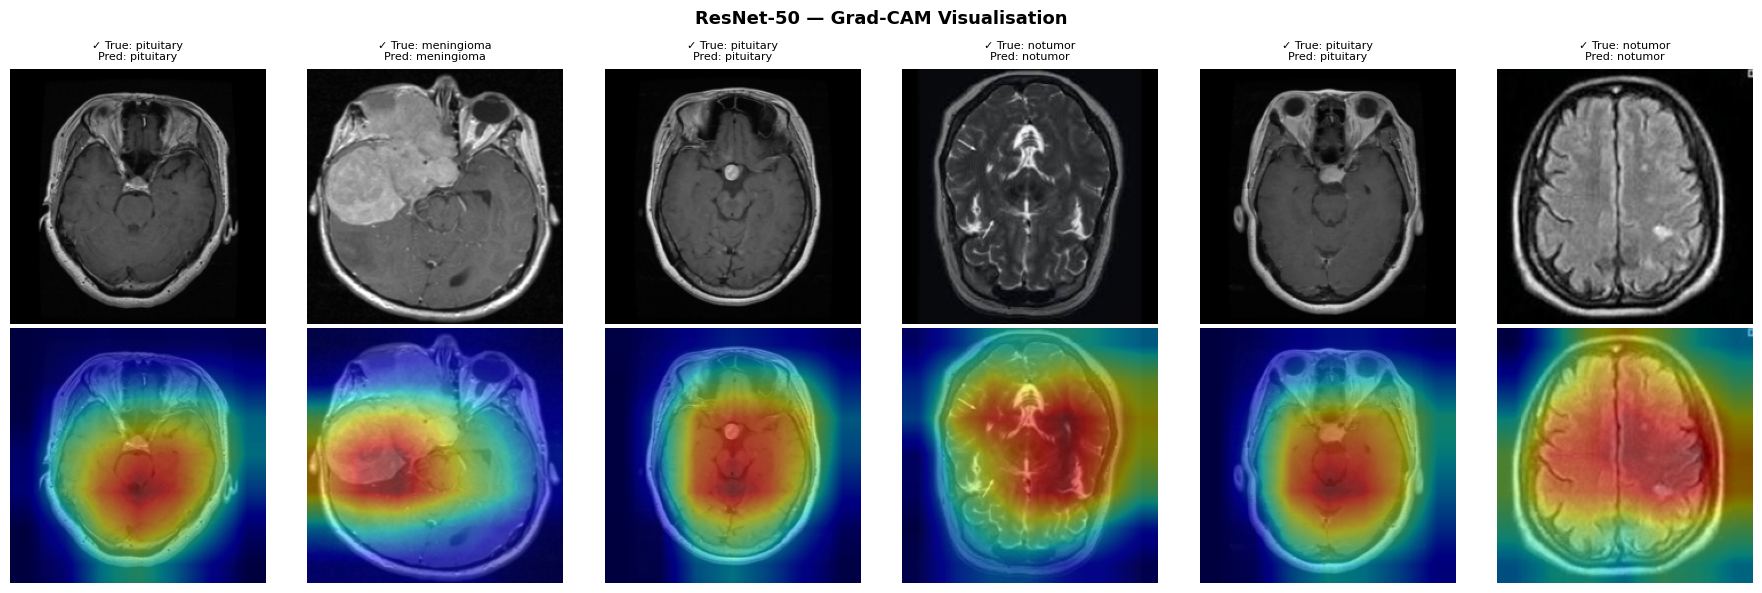

In [26]:
def visualize_gradcam(
    model: nn.Module,
    dataset: Dataset,
    gradcam: GradCAM,
    device: torch.device,
    n_samples: int = 6,
) -> None:
    inv_norm = transforms.Normalize(
        mean=[-m / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
        std=[1.0 / s for s in IMAGENET_STD],
    )

    indices = random.sample(range(len(dataset)), n_samples)
    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))

    for col, idx in enumerate(indices):
        img_t, true_label = dataset[idx]
        batch = img_t.unsqueeze(0)

        cam = gradcam.compute(batch)
        cam_img = Image.fromarray((cam * 255).astype(np.uint8))
        cam_img = cam_img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        cam_np  = np.array(cam_img) / 255.0

        with torch.no_grad():
            pred = model(batch.to(device)).argmax(1).item()

        orig = inv_norm(img_t).clamp(0, 1).permute(1, 2, 0).numpy()

        heatmap = cm.jet(cam_np)[:, :, :3]
        overlay = np.clip(0.50 * orig + 0.50 * heatmap, 0, 1)

        match = '✓' if pred == true_label else '✗'
        axes[0, col].imshow(orig)
        axes[0, col].set_title(f'{match} True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred]}', fontsize=8)
        axes[0, col].axis('off')
        axes[1, col].imshow(overlay)
        axes[1, col].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=10)
    axes[1, 0].set_ylabel('Grad-CAM', fontsize=10)
    plt.suptitle('ResNet-50 — Grad-CAM Visualisation', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Instantiate Grad-CAM targeting the last residual block in layer4
# resnet_model_pretrained already holds its best (highest val-acc) weights here --
# either freshly trained-and-reloaded, or restored straight from the Drive cache.
gradcam = GradCAM(resnet_model_pretrained, target_layer=resnet_model_pretrained.model.layer4[-1])

visualize_gradcam(resnet_model_pretrained, test_ds, gradcam, device, n_samples=6)

gradcam.remove_hooks()   # clean up hooks to free memory

---
## **Section 5 — Advanced Stage: Vision Transformer (ViT-B/16)**

In this final stage, we implement an advanced, attention-based architecture to shift our paradigm from local feature aggregation to global context modeling.

#### **Our Approach: Self-Attention vs. Local Convolutions**

Traditional CNNs build global context **incrementally**: a $3 \times 3$ kernel only sees a restricted local neighborhood, requiring us to stack dozens of layers before the network can correlate distant image regions.  
In contrast, our **Vision Transformer (ViT)** achieves **global context in every single layer** through Multi-Head Self-Attention (MHSA):

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

### **How We Process the Input:**
* **Patch Extraction:** We divide the $224 \times 224$ MRI image into **196 non-overlapping $16 \times 16$ patches**.
* **Linear Embedding:** Each patch is linearly projected into a 768-dimensional vector space.
* **Dense Attention Matrix:** Through MHSA, we compute a complete $196 \times 196$ attention matrix. This allows every single patch to directly attend to every other patch across the entire scan in a single, parallelized operation.

### **Why This Matters for Brain Tumor Detection:**
For our specific clinical task, this global capacity is crucial. Rather than relying on local textures alone, our model can directly relate a suspicious tissue region to structural macro-indicators, such as a **midline shift** or **ventricular asymmetry** on the opposite side of the brain scan. These are long-range spatial relationships that a CNN would struggle to capture without an incredibly deep hierarchy of layers.

In [ ]:
class ViTClassifier(nn.Module):
    '''
    ViT-B/16 fine-tuned for 4-class brain tumour classification.

    Architecture overview:
      1. Patch embedding — splits 224×224 into 196 patches of 16×16,
         linearly maps each to a 768-d token.
      2. [CLS] token — a learnable token prepended to the sequence;
         its final state is used for classification.
      3. Positional encoding — learnable 1-D positional embeddings added
         to every token so the model knows spatial order.
      4. 12× Transformer encoder blocks, each containing:
           a. Layer Norm
           b. Multi-Head Self-Attention (12 heads, head_dim=64)
           c. Layer Norm
           d. MLP (768 → 3072 → 768, GELU activation)
         Residual connections wrap both sub-layers.
      5. Classification head — applied to the [CLS] token output.

    Step (4b) is the core: the Q, K, V projections of ALL 197 tokens
    (196 patches + 1 CLS) interact simultaneously.  The softmax attention
    weights are a 197×197 matrix learned per head per block — capturing
    arbitrary long-range spatial dependencies in a single layer.
    '''

    def __init__(self, num_classes: int = 4, dropout: float = 0.3):
        super().__init__()
        weights   = models.ViT_B_16_Weights.IMAGENET1K_V1
        self.vit  = models.vit_b_16(weights=weights)

        # Replace the original 1000-class head with a 4-class head.
        # ViT-B/16 hidden_dim = 768 (dimension of every token embedding).
        hidden_dim = 768
        self.vit.heads = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        '''
        Full ViT forward pass:
          x (B, 3, 224, 224)
          → patch tokens (B, 196, 768)
          → prepend [CLS], add pos encoding  (B, 197, 768)
          → 12 × (MHSA + FFN)               (B, 197, 768)
          → [CLS] token output               (B, 768)
          → classification head              (B, num_classes)
        '''
        return self.vit(x)


vit_model       = ViTClassifier(NUM_CLASSES).to(device)
total_vit       = sum(p.numel() for p in vit_model.parameters())
trainable_vit   = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'ViT-B/16 total parameters    : {total_vit:,}')
print(f'ViT-B/16 trainable parameters: {trainable_vit:,}')

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 184MB/s]


ViT-B/16 total parameters    : 85,801,732
ViT-B/16 trainable parameters: 85,801,732


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ViT-B/16]  Epoch   1/15  |  Train Acc. 0.9717  Val Acc. 0.9625  LR 2.00e-05   Val Loss 0.1278


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ViT-B/16]  Epoch   2/15  |  Train Acc. 0.9775  Val Acc. 0.9679  LR 2.00e-05   Val Loss 0.0798


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ViT-B/16]  Epoch   3/15  |  Train Acc. 0.9864  Val Acc. 0.9661  LR 1.97e-05   Val Loss 0.1017


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ViT-B/16]  Epoch   4/15  |  Train Acc. 0.9891  Val Acc. 0.9714  LR 1.89e-05   Val Loss 0.1048


  train:   0%|          | 0/140 [00:00<?, ?it/s]

[ViT-B/16]  Epoch   5/15  |  Train Acc. 0.9911  Val Acc. 0.9750  LR 1.75e-05   Val Loss 0.1108
Early stopping at epoch 5, no val-loss improvement in 3 epochs.

Best ViT-B/16 Val Accuracy: 0.9679
  -> saved checkpoint: /content/drive/MyDrive/brain_tumor_project/checkpoints/vit.pt


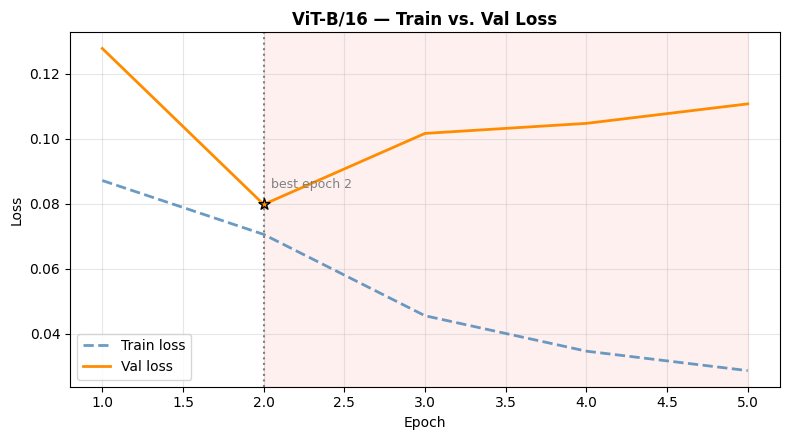

Lowest val loss at epoch 2/15 -> early stopping here would have kept the best-generalising weights.


In [ ]:
VIT_EPOCHS = 15
VIT_LR     = 2e-5   # small LR: large pre-trained Transformer is sensitive to big updates
PATIENCE = 3

FORCE_RETRAIN_VIT = True

cached = None if FORCE_RETRAIN_VIT else load_checkpoint('vit')

if cached is not None:
    vit_model.load_state_dict(cached['model_state'])
    h = cached['history']
    vit_train_accs, vit_val_accs     = h['train_accs'], h['val_accs']
    vit_train_losses, vit_val_losses = h['train_losses'], h['val_losses']
    best_vit_val_acc                 = h['best_val_acc']
    print(f'Best ViT-B/16 Val Accuracy (cached): {best_vit_val_acc:.4f}')
else:
    vit_criterion = nn.CrossEntropyLoss()
    vit_optimizer = optim.AdamW(vit_model.parameters(), lr=VIT_LR, weight_decay=0.01)

    # Linear warm-up for the first 2 epochs, then cosine decay — standard for ViT fine-tuning
    WARMUP = 2
    def _lr_lambda(epoch: int) -> float:
        if epoch < WARMUP:
            return float(epoch + 1) / float(WARMUP)
        progress = float(epoch - WARMUP) / float(max(1, VIT_EPOCHS - WARMUP))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))

    vit_scheduler = optim.lr_scheduler.LambdaLR(vit_optimizer, _lr_lambda)

    vit_train_accs, vit_val_accs = [], []
    vit_train_losses, vit_val_losses = [], []
    best_vit_val_acc = 0.0
    best_val_loss = float('inf')

    for epoch in range(1, VIT_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(vit_model, train_loader,
                                           vit_criterion, vit_optimizer, device)
        vl_loss, vl_acc = evaluate(vit_model, val_loader, vit_criterion, device)
        vit_scheduler.step()

        vit_train_accs.append(tr_acc)
        vit_val_accs.append(vl_acc)
        vit_train_losses.append(tr_loss)
        vit_val_losses.append(vl_loss)
        lr_now = vit_optimizer.param_groups[0]['lr']
        print(f'[ViT-B/16]  Epoch {epoch:3d}/{VIT_EPOCHS}  |'
              f'  Train Acc. {tr_acc:.4f}  Val Acc. {vl_acc:.4f}  LR {lr_now:.2e}   Val Loss {vl_loss:.4f}')

        if vl_loss < best_val_loss:
          best_val_loss = vl_loss
          best_vit_val_acc = vl_acc
          epochs_no_improve = 0
          torch.save(vit_model.state_dict(), '/content/best_vit.pth')
        else:
          epochs_no_improve += 1
          if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}, no val-loss improvement in {PATIENCE} epochs.")
            break

    print(f'\nBest ViT-B/16 Val Accuracy: {best_vit_val_acc:.4f}')

    # Reload the best (highest val-acc) epoch's weights before caching/evaluating
    vit_model.load_state_dict(torch.load('/content/best_vit.pth', map_location=device))
    save_checkpoint('vit', vit_model, {
        'train_accs': vit_train_accs, 'val_accs': vit_val_accs,
        'train_losses': vit_train_losses, 'val_losses': vit_val_losses,
        'best_val_acc': best_vit_val_acc,
    })

vit_best_epoch = plot_loss_curve(vit_train_losses, vit_val_losses,
                                  'ViT-B/16 — Train vs. Val Loss')
print(f'Lowest val loss at epoch {vit_best_epoch}/{VIT_EPOCHS} '
      '-> early stopping here would have kept the best-generalising weights.')

## **Section 7 — Evaluation & Comparison**

In this final section, we conduct a comprehensive performance evaluation and comparative analysis across our three developed architectures.

#### **Our Evaluation Methodology:**
To guarantee an un**biased** and scientifically rigorous assessment, we evaluate all three models exclusively on the **held-out testing folder**. This dataset was strictly isolated and never seen by any of the networks during their respective training or validation phases.

We compare the models across key classification metrics—including **Accuracy**, **Precision**, **Recall**, **F1-Score**, and **Confusion Matrices**—to identify the strengths and trade-offs of each architectural approach.Additionally, we visualize the **training convergence profiles** to analyze how effectively each model learned across epochs.

In [ ]:
def collect_predictions(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> Tuple[np.ndarray, np.ndarray]:
    '''
    Run `model` on `loader` and collect all predictions and ground-truth labels.

    Returns:
        preds  : (N,) integer array of predicted class indices
        labels : (N,) integer array of ground-truth class indices
    '''
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labs in tqdm(loader, leave=False, desc='  testing'):
            images = images.to(device)
            preds  = model(images).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labs.numpy())

    return np.array(all_preds), np.array(all_labels)


def report_and_plot(
    model_name: str,
    preds: np.ndarray,
    labels: np.ndarray,
    class_names: List[str],
) -> None:
    '''Print classification report and display the confusion matrix.'''
    print(f'\n{"=" * 60}')
    print(f'  {model_name}  —  Test Set Results')
    print(f'{"=" * 60}')
    print(classification_report(labels, preds, target_names=class_names, digits=4))

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Models already hold their best (early-stopped) weights ───────────────────
# Each training cell above already reloaded its own best checkpoint (or restored
# it directly from the Drive cache), so no extra loading is needed here.

# ── Run test-set evaluation ───────────────────────────────────────────────────
print('Running inference on the test set ...')
cae_preds,    cae_labels    = collect_predictions(cae_classifier, test_loader, device)
resnet_preds, resnet_labels = collect_predictions(resnet_model,   test_loader, device)
vit_preds,    vit_labels    = collect_predictions(vit_model,      test_loader, device)

# ── Per-model report + confusion matrix ──────────────────────────────────────
report_and_plot('CAE Classifier',  cae_preds,    cae_labels,    CLASS_NAMES)
report_and_plot('ResNet-50',        resnet_preds, resnet_labels, CLASS_NAMES)
report_and_plot('ViT-B/16',         vit_preds,    vit_labels,    CLASS_NAMES)

In [ ]:
# ── Final comparison visualisation ───────────────────────────────────────────

COLORS = ['steelblue', 'darkorange', 'mediumseagreen']
MODEL_LABELS = [
    ('CAE Classifier', cae_train_accs,    cae_val_accs,    COLORS[0]),
    ('ResNet-50',       rn_train_accs,     rn_val_accs,     COLORS[1]),
    ('ViT-B/16',        vit_train_accs,    vit_val_accs,    COLORS[2]),
]

# ── (A) Accuracy curves per model ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (name, tr_acc, vl_acc, color) in zip(axes, MODEL_LABELS):
    ax.plot(tr_acc, label='Train', linewidth=2, linestyle='--', color=color, alpha=0.7)
    ax.plot(vl_acc, label='Val',   linewidth=2, color=color)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Accuracy Progression Across Training Stages', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── (B) Train vs. Val loss curves per model — early-stopping check ───────────
LOSS_LABELS = [
    ('CAE Classifier', cae_train_losses, cae_val_losses, cae_best_epoch),
    ('ResNet-50',       rn_train_losses,  rn_val_losses,  rn_best_epoch),
    ('ViT-B/16',        vit_train_losses, vit_val_losses, vit_best_epoch),
]

fig_loss, axes_loss = plt.subplots(1, 3, figsize=(17, 5))
for ax, (name, tr_loss_hist, vl_loss_hist, best_ep) in zip(axes_loss, LOSS_LABELS):
    plot_loss_curve(tr_loss_hist, vl_loss_hist, name, ax=ax)

plt.suptitle('Train vs. Validation Loss — Early Stopping Diagnostic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Best (lowest val-loss) epoch per model:')
for name, _, _, best_ep in LOSS_LABELS:
    print(f'  {name:<16} epoch {best_ep}')
print('If a curve\'s val loss keeps falling alongside train loss, more epochs (or a later'
      ' stopping point) may still help; if val loss turns upward while train loss keeps'
      ' dropping, that divergence point is where early stopping should trigger.')

# ── (B) Bar chart: final test accuracy ────────────────────────────────────────
test_accs = [
    accuracy_score(cae_labels,    cae_preds),
    accuracy_score(resnet_labels, resnet_preds),
    accuracy_score(vit_labels,    vit_preds),
]
bar_labels = ['CAE\nClassifier', 'ResNet-50', 'ViT-B/16']

fig2, ax2 = plt.subplots(figsize=(7, 5))
bars = ax2.bar(bar_labels, test_accs, color=COLORS,
               width=0.5, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, test_accs):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{acc:.4f}',
        ha='center', va='bottom', fontsize=12, fontweight='bold',
    )
ax2.set_title('Final Test Accuracy — Model Comparison', fontsize=13, fontweight='bold')
ax2.set_ylabel('Test Accuracy')
ax2.set_ylim(0, 1.15)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n' + '=' * 45)
print(f'  {"Model":<22}  Test Accuracy')
print('=' * 45)
for name, acc in zip(['CAE Classifier', 'ResNet-50', 'ViT-B/16'], test_accs):
    print(f'  {name:<22}  {acc:.4f}')
print('=' * 45)